# Layout-Type Classifier — Full-Document

6-class classification of each page's **layout type** using all pages in every dossier.

| Label | Class |
|-------|-------|
| 0 | Card (Index Card) |
| 1 | Cover |
| 2 | Letter |
| 3 | Other |
| 4 | Photo |
| 5 | Structured Form |

**Label source**: `annotation 1–4.xlsx`.  
5 dossiers labelled by all 4 annotators → **majority vote** (mode; ties broken by annotator 1).  
15 unique dossiers per annotator → single annotator label.

Three modality families are explored:

| # | Modality | Models |
|---|----------|--------|
| A | **Image only** | KNN+VGG-16, XGBoost+VGG-16, VGG-16 FT, EfficientNet-B0 FT, LSTM+VGG-16 |
| B | **Text only** | KNN+BERT, XGBoost+BERT, TEXT-CNN, BERT FT |
| C | **Fusion** | KNN-Ensemble, XGBoost-Ensemble, Early Fusion (EfficientNet+BERT→MLP), Late Fusion (avg softmax) |

## 1. Setup

In [1]:
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

WORKSPACE  = Path('/Users/yeqianli/Desktop/data segmentation')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
TEXT_ROOT  = WORKSPACE / 'outputs' / 'page_text_by_page'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Canonical layout-type class mapping ──────────────────────────────────────
CLASS_NAMES = [
    'Card (Index Card)',   # 0
    'Cover',               # 1
    'Letter',              # 2
    'Other',               # 3
    'Photo',               # 4
    'Structured Form',     # 5
]
SHORT_NAMES  = ['Card', 'Cover', 'Letter', 'Other', 'Photo', 'Form']
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

BERT_MODEL = 'bert-base-uncased'

print('Classes:', CLASS_NAMES)

Device: cpu
Classes: ['Card (Index Card)', 'Cover', 'Letter', 'Other', 'Photo', 'Structured Form']


## 2. Load Annotations & Build Labels

In [2]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier']  = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num'] = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num'])

    # Primary layout label; override takes precedence when present
    df['layout_raw'] = df['Layout Type Classification'].astype(str).str.strip()
    if 'layout override' in df.columns:
        override = df['layout override'].astype(str).str.strip()
        has_override = override.notna() & (override != '') & (override.str.lower() != 'nan')
        df.loc[has_override, 'layout_raw'] = override[has_override]

    # Keep only known classes
    df = df[df['layout_raw'].isin(CLASS_TO_IDX)].copy()
    df['label'] = df['layout_raw'].map(CLASS_TO_IDX).astype(int)
    return df[['dossier', 'page_num', 'label']]


ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

dossier_sets    = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')
for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique (non-shared): {len(s - common_dossiers)}')

Common dossiers (5): ['a2478-boer-j-1452187', 'a2478-de-waal-g-l-m-1451034', 'a2478-derksen-a-l-1444766', 'a2478-eijkel-r-1451358', 'a2478-hanssen-g-h-1470445']
Annotation 1: 20 dossiers  |  unique (non-shared): 15
Annotation 2: 20 dossiers  |  unique (non-shared): 15
Annotation 3: 20 dossiers  |  unique (non-shared): 15
Annotation 4: 20 dossiers  |  unique (non-shared): 15


In [3]:
# ── Majority-vote labels for the 5 shared dossiers ───────────────────────────
shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'label': f'label_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = shared_frames[0]
for f in shared_frames[1:]:
    shared = shared.join(f, how='outer')

label_cols = [f'label_{i}' for i in range(1, 5)]

def majority_vote(row):
    """Mode of available votes; tie → first annotator's value."""
    votes = row[label_cols].dropna().astype(int)
    if votes.empty:
        return np.nan
    return int(votes.mode().iloc[0])

shared['label'] = shared.apply(majority_vote, axis=1)
shared = shared.dropna(subset=['label'])
shared['label'] = shared['label'].astype(int)
shared = shared.reset_index()[['dossier', 'page_num', 'label']]
print(f'Shared dossiers pages: {len(shared)}')

# ── Labels for the 15 unique dossiers per annotator ──────────────────────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)]
    unique_frames.append(sub[['dossier', 'page_num', 'label']])

unique_labels = pd.concat(unique_frames, ignore_index=True)
print(f'Unique dossiers pages: {len(unique_labels)}')

# ── Final label table ─────────────────────────────────────────────────────────
all_labels = pd.concat([shared, unique_labels], ignore_index=True)
all_labels = all_labels.drop_duplicates(subset=['dossier', 'page_num'])
all_labels = all_labels.sort_values(['dossier', 'page_num']).reset_index(drop=True)

print(f'\nTotal pages: {len(all_labels)}')
dist = all_labels['label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx} {CLASS_NAMES[idx]:25s}  {count:4d}  ({count/len(all_labels)*100:.1f}%)')

Shared dossiers pages: 170
Unique dossiers pages: 2241

Total pages: 2411
  0 Card (Index Card)           102  (4.2%)
  1 Cover                        65  (2.7%)
  2 Letter                      656  (27.2%)
  3 Other                        93  (3.9%)
  4 Photo                       205  (8.5%)
  5 Structured Form            1290  (53.5%)


## 3. Build Image & Text Paths

In [4]:
def img_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

def text_path(dossier: str, page_num: int) -> Path:
    return TEXT_ROOT / dossier / 'page' / f'page_{int(page_num):04d}.txt'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

all_labels['img_path']  = all_labels.apply(
    lambda r: img_path(r['dossier'], r['page_num']), axis=1)
all_labels['text_path'] = all_labels.apply(
    lambda r: text_path(r['dossier'], r['page_num']), axis=1)

exists_mask = all_labels['img_path'].map(lambda p: p.exists())
missing = (~exists_mask).sum()
print(f'Missing PNGs: {missing} / {len(all_labels)}')
all_labels = all_labels[exists_mask].reset_index(drop=True)
print(f'Usable pages: {len(all_labels)}')
all_labels.head()

Missing PNGs: 0 / 2411
Usable pages: 2411


,dossier,page_num,label,img_path,text_path
0,a2478-ambachtsheer-p-1214053,1,1,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
1,a2478-ambachtsheer-p-1214053,2,4,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
2,a2478-ambachtsheer-p-1214053,3,4,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
3,a2478-ambachtsheer-p-1214053,4,5,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
4,a2478-ambachtsheer-p-1214053,5,5,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...


## 4. Train / Validation / Test Split (dossier-level)

In [5]:
dossiers_all = all_labels['dossier'].unique()
train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,  test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

all_labels['split'] = all_labels['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = all_labels[all_labels['split'] == s]
    print(f'{s:6s}: {len(sub):4d} pages  |  '
          + '  '.join(f'{i}:{int((sub["label"]==i).sum())}' for i in range(NUM_CLASSES)))

idx_tr = all_labels[all_labels['split'] == 'train'].index
idx_va = all_labels[all_labels['split'] == 'val'].index
idx_te = all_labels[all_labels['split'] == 'test'].index

df_tr = all_labels.loc[idx_tr]
df_va = all_labels.loc[idx_va]
df_te = all_labels.loc[idx_te]

y_tr = all_labels.loc[idx_tr, 'label'].values
y_va = all_labels.loc[idx_va, 'label'].values
y_te = all_labels.loc[idx_te, 'label'].values

train : 1706 pages  |  0:74  1:45  2:476  3:65  4:132  5:914
val   :  367 pages  |  0:17  1:10  2:91  3:17  4:27  5:205
test  :  338 pages  |  0:11  1:10  2:89  3:11  4:46  5:171


## 5. Feature Extraction

### 5a. VGG-16 Image Features (cached)

4096-D penultimate FC features extracted from pre-trained VGG-16 (ImageNet).

In [6]:
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

VGG_CACHE = CACHE_DIR / 'vgg16_features.npz'

if VGG_CACHE.exists():
    print('Loading cached VGG-16 features …')
    cache = np.load(VGG_CACHE, allow_pickle=True)
    X_vgg_cache  = cache['X_all']
    cached_paths = {p: i for i, p in enumerate(cache['path_strs'])}

    img_strs = all_labels['img_path'].map(str)
    hit = img_strs.map(lambda p: p in cached_paths)
    X_vgg = np.zeros((len(all_labels), 4096), dtype=np.float32)
    if hit.all():
        X_vgg = X_vgg_cache[img_strs.map(lambda p: cached_paths[p]).values]
        print(f'All {len(X_vgg)} VGG features loaded from cache.')
    else:
        print(f'{(~hit).sum()} paths not in cache — extracting missing …')
        vgg_ext  = VGG16FeatureExtractor(device=DEVICE)
        hit_idx  = all_labels[hit].index
        miss_idx = all_labels[~hit].index
        X_vgg[hit_idx]  = X_vgg_cache[img_strs[hit_idx].map(lambda p: cached_paths[p]).values]
        X_vgg[miss_idx] = vgg_ext.encode_paths(all_labels.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting VGG-16 features (may take a while) …')
    vgg_ext = VGG16FeatureExtractor(device=DEVICE)
    X_vgg   = vgg_ext.encode_paths(all_labels['img_path'].tolist(), batch_size=16)
    np.savez_compressed(VGG_CACHE,
                        X_all=X_vgg,
                        path_strs=all_labels['img_path'].map(str).values)
    print(f'Saved {len(X_vgg)} features to cache.')

X_vgg_tr = X_vgg[idx_tr]
X_vgg_va = X_vgg[idx_va]
X_vgg_te = X_vgg[idx_te]
print(f'VGG  train: {X_vgg_tr.shape}, val: {X_vgg_va.shape}, test: {X_vgg_te.shape}')

Loading cached VGG-16 features …
All 2411 VGG features loaded from cache.
VGG  train: (1706, 4096), val: (367, 4096), test: (338, 4096)


### 5b. EfficientNet-B0 Image Features (cached)

1280-D global-average-pooled features extracted from pre-trained EfficientNet-B0.

In [8]:
EFF_CACHE = CACHE_DIR / 'efficientnet_features_layout.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = models.efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()   # 1280-D pooled output
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            chunk = paths[start:start + batch_size]
            tensors = []
            for p in chunk:
                with Image.open(p).convert('RGB') as im:
                    tensors.append(preprocess(im))
            xb   = torch.stack(tensors).to(DEVICE)
            feat = eff(xb).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X

if EFF_CACHE.exists():
    print('Loading cached EfficientNet features …')
    cache = np.load(EFF_CACHE, allow_pickle=True)
    X_eff_cache      = cache['X_all']
    cached_eff_paths = {p: i for i, p in enumerate(cache['path_strs'])}
    img_strs = all_labels['img_path'].map(str)
    hit = img_strs.map(lambda p: p in cached_eff_paths)
    X_eff = np.zeros((len(all_labels), 1280), dtype=np.float32)
    if hit.all():
        X_eff = X_eff_cache[img_strs.map(lambda p: cached_eff_paths[p]).values]
        print(f'All {len(X_eff)} EfficientNet features from cache.')
    else:
        hit_idx  = all_labels[hit].index
        miss_idx = all_labels[~hit].index
        X_eff[hit_idx]  = X_eff_cache[img_strs[hit_idx].map(lambda p: cached_eff_paths[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(all_labels.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting EfficientNet-B0 features …')
    X_eff = extract_efficientnet_features(all_labels['img_path'].tolist())
    np.savez_compressed(EFF_CACHE,
                        X_all=X_eff,
                        path_strs=all_labels['img_path'].map(str).values)
    print(f'Saved {len(X_eff)} EfficientNet features.')

X_eff_tr = X_eff[idx_tr]
X_eff_va = X_eff[idx_va]
X_eff_te = X_eff[idx_te]
print(f'EfficientNet  train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')

Loading cached EfficientNet features …
All 2411 EfficientNet features from cache.
EfficientNet  train: (1706, 1280), val: (367, 1280), test: (338, 1280)


### 5c. BERT [CLS] Text Features (cached)

768-D `[CLS]` token embeddings from frozen `bert-base-uncased`, extracted from per-page `.txt` files.

In [10]:
BERT_CACHE = CACHE_DIR / 'bert_features_layout.npz'

def extract_bert_cls_features(
    text_paths: list,
    model_name: str = BERT_MODEL,
    batch_size: int = 32,
    max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False

    texts  = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            X[start:start + len(chunk)] = cls
    return X


if BERT_CACHE.exists():
    print('Loading cached BERT features …')
    cache = np.load(BERT_CACHE, allow_pickle=True)
    X_bert_cache      = cache['X_all']
    cached_bert_paths = {p: i for i, p in enumerate(cache['path_strs'])}
    txt_strs = all_labels['text_path'].map(str)
    hit = txt_strs.map(lambda p: p in cached_bert_paths)
    X_bert = np.zeros((len(all_labels), 768), dtype=np.float32)
    if hit.all():
        X_bert = X_bert_cache[txt_strs.map(lambda p: cached_bert_paths[p]).values]
        print(f'All {len(X_bert)} BERT features from cache.')
    else:
        hit_idx  = all_labels[hit].index
        miss_idx = all_labels[~hit].index
        X_bert[hit_idx]  = X_bert_cache[txt_strs[hit_idx].map(lambda p: cached_bert_paths[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(all_labels.loc[miss_idx, 'text_path'].tolist())
else:
    print('Extracting BERT [CLS] features')
    X_bert = extract_bert_cls_features(all_labels['text_path'].tolist())
    np.savez_compressed(BERT_CACHE,
                        X_all=X_bert,
                        path_strs=all_labels['text_path'].map(str).values)
    print(f'Saved {len(X_bert)} BERT features.')

X_bert_tr = X_bert[idx_tr]
X_bert_va = X_bert[idx_va]
X_bert_te = X_bert[idx_te]
print(f'BERT  train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')

Extracting BERT [CLS] features
Saved 2411 BERT features.
BERT  train: (1706, 768), val: (367, 768), test: (338, 768)


## 6. Utility Helpers

In [11]:
results = {}

def class_weights_tensor(y: np.ndarray, n_classes: int, device) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = 1.0 / counts
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32).to(device)


def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray,
             split: str = 'test') -> dict:
    acc   = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n── {name} [{split}] ──')
    print(f'  Accuracy: {acc:.4f}  |  Macro-F1: {macro:.4f}')
    print(classification_report(y_true, y_pred, target_names=SHORT_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — {split}')
    plt.tight_layout()
    plt.show()
    return {'accuracy': acc, 'macro_f1': macro}


# ── Shared image transforms ───────────────────────────────────────────────────
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class PageImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['label'].tolist()
        self.tf     = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]).convert('RGB') as im:
            img = self.tf(im)
        return img, self.labels[i]


def make_image_loaders(df_tr, df_va, df_te, batch=32):
    tr = DataLoader(PageImageDataset(df_tr, TRAIN_TF), batch_size=batch, shuffle=True,  num_workers=0)
    va = DataLoader(PageImageDataset(df_va, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    te = DataLoader(PageImageDataset(df_te, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    return tr, va, te


def train_finetune(
    model, tr_loader, va_loader,
    n_epochs=15, lr=1e-4, weight_decay=1e-5,
):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in va_loader:
                preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_image_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Helpers defined.')

Helpers defined.


---
## 7. Image-Only Models

### 7a. KNN + VGG-16

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


k= 3  val macro-F1=0.7663
k= 5  val macro-F1=0.7663
k= 7  val macro-F1=0.7757
k=11  val macro-F1=0.7659
k=15  val macro-F1=0.7664

Best k=7

── KNN-VGG16 [val] ──
  Accuracy: 0.8992  |  Macro-F1: 0.7757
              precision    recall  f1-score   support

        Card       0.89      0.94      0.91        17
       Cover       1.00      1.00      1.00        10
      Letter       0.75      0.93      0.83        91
       Other       0.00      0.00      0.00        17
       Photo       1.00      0.89      0.94        27
        Form       0.98      0.95      0.97       205

    accuracy                           0.90       367
   macro avg       0.77      0.79      0.78       367
weighted avg       0.88      0.90      0.88       367



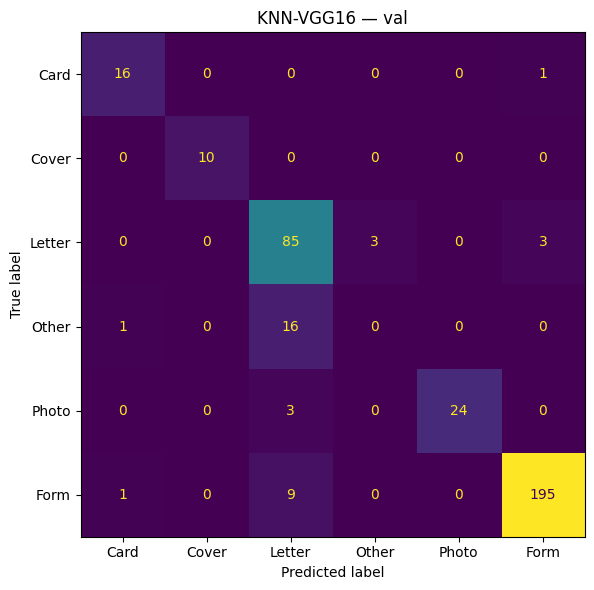


── KNN-VGG16 [test] ──
  Accuracy: 0.8846  |  Macro-F1: 0.7602
              precision    recall  f1-score   support

        Card       1.00      0.91      0.95        11
       Cover       1.00      1.00      1.00        10
      Letter       0.74      0.91      0.81        89
       Other       0.00      0.00      0.00        11
       Photo       1.00      0.72      0.84        46
        Form       0.95      0.96      0.96       171

    accuracy                           0.88       338
   macro avg       0.78      0.75      0.76       338
weighted avg       0.87      0.88      0.87       338



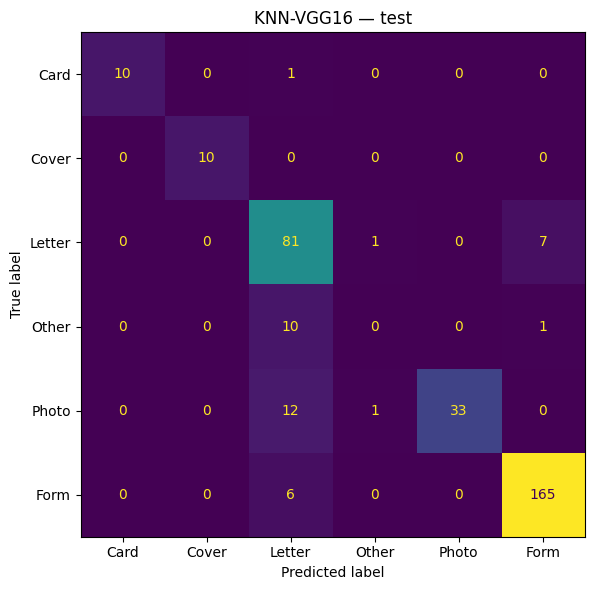

In [12]:
X_vgg_tr_n = normalize(X_vgg_tr)
X_vgg_va_n = normalize(X_vgg_va)
X_vgg_te_n = normalize(X_vgg_te)

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_vgg_tr_n, y_tr)
    f1 = f1_score(y_va, knn.predict(X_vgg_va_n), average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_vgg = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_vgg.fit(X_vgg_tr_n, y_tr)
pred_knn_vgg_te = knn_vgg.predict(X_vgg_te_n)

evaluate('KNN-VGG16', y_va, knn_vgg.predict(X_vgg_va_n), 'val')
results['KNN-VGG16'] = evaluate('KNN-VGG16', y_te, pred_knn_vgg_te, 'test')
results['KNN-VGG16']['preds_te'] = pred_knn_vgg_te

### 7b. XGBoost + VGG-16


── XGBoost-VGG16 [val] ──
  Accuracy: 0.8719  |  Macro-F1: 0.7701
              precision    recall  f1-score   support

        Card       0.94      0.88      0.91        17
       Cover       1.00      1.00      1.00        10
      Letter       0.72      0.85      0.78        91
       Other       0.00      0.00      0.00        17
       Photo       1.00      1.00      1.00        27
        Form       0.94      0.93      0.93       205

    accuracy                           0.87       367
   macro avg       0.77      0.78      0.77       367
weighted avg       0.85      0.87      0.86       367



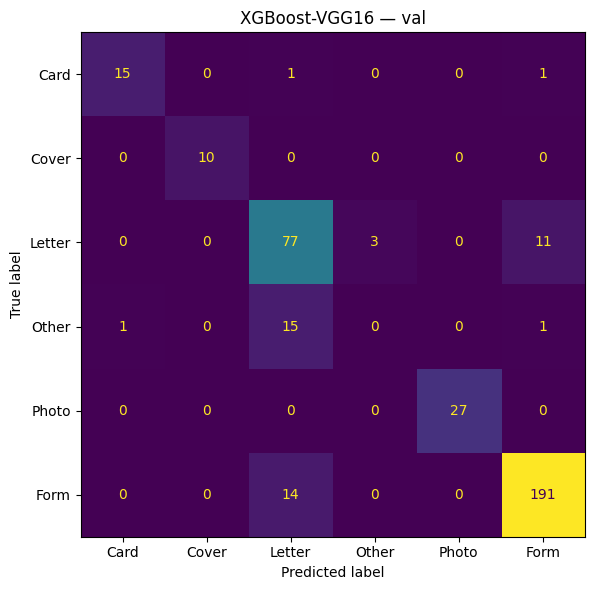


── XGBoost-VGG16 [test] ──
  Accuracy: 0.9083  |  Macro-F1: 0.7882
              precision    recall  f1-score   support

        Card       1.00      1.00      1.00        11
       Cover       1.00      1.00      1.00        10
      Letter       0.79      0.90      0.84        89
       Other       0.00      0.00      0.00        11
       Photo       1.00      0.87      0.93        46
        Form       0.94      0.97      0.96       171

    accuracy                           0.91       338
   macro avg       0.79      0.79      0.79       338
weighted avg       0.88      0.91      0.89       338



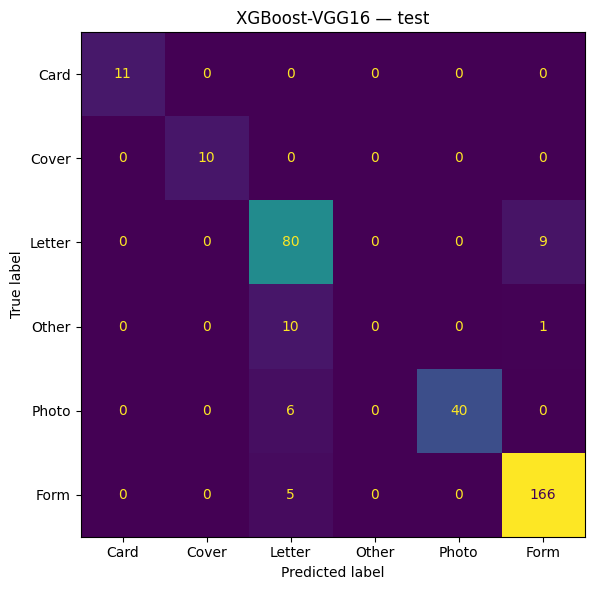

In [13]:
xgb_vgg = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_vgg.fit(X_vgg_tr, y_tr, eval_set=[(X_vgg_va, y_va)], verbose=False)
pred_xgb_vgg_te = xgb_vgg.predict(X_vgg_te)

evaluate('XGBoost-VGG16', y_va, xgb_vgg.predict(X_vgg_va), 'val')
results['XGBoost-VGG16'] = evaluate('XGBoost-VGG16', y_te, pred_xgb_vgg_te, 'test')
results['XGBoost-VGG16']['preds_te'] = pred_xgb_vgg_te

### 7c. VGG-16 Fine-Tuned (end-to-end)

VGG-16 fine-tune …
  Epoch  1  val_macro_f1=0.7722
  Epoch  2  val_macro_f1=0.7552
  Epoch  3  val_macro_f1=0.7762
  Epoch  4  val_macro_f1=0.8051
  Epoch  5  val_macro_f1=0.7985
  Epoch  6  val_macro_f1=0.7820
  Epoch  7  val_macro_f1=0.7791
  Epoch  8  val_macro_f1=0.7842
  Epoch  9  val_macro_f1=0.7895
  Epoch 10  val_macro_f1=0.7926
  Epoch 11  val_macro_f1=0.7811
  Epoch 12  val_macro_f1=0.7933
  Epoch 13  val_macro_f1=0.7870
  Epoch 14  val_macro_f1=0.7940
  Epoch 15  val_macro_f1=0.7897

── VGG-16 Fine-Tuned [test] ──
  Accuracy: 0.7160  |  Macro-F1: 0.7187
              precision    recall  f1-score   support

        Card       0.82      0.82      0.82        11
       Cover       1.00      1.00      1.00        10
      Letter       0.69      0.57      0.63        89
       Other       0.08      0.55      0.14        11
       Photo       1.00      0.76      0.86        46
        Form       1.00      0.77      0.87       171

    accuracy                           0.72      

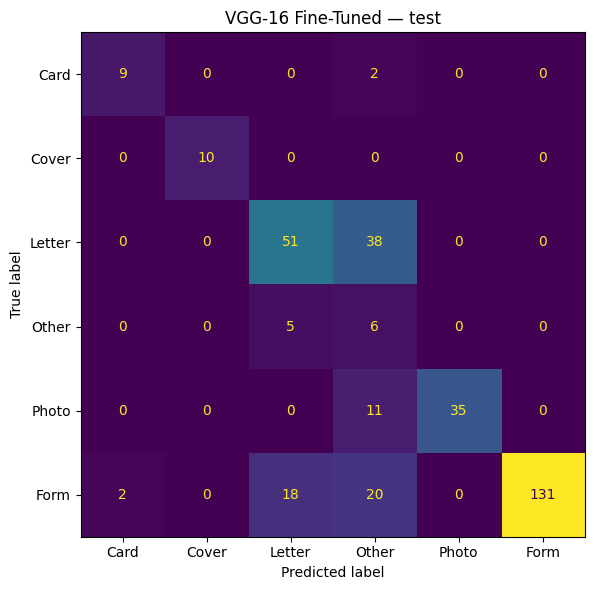

In [14]:
tr_img_loader, va_img_loader, te_img_loader = make_image_loaders(df_tr, df_va, df_te, batch=32)

vgg_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for p in vgg_ft.features.parameters():
    p.requires_grad = False
vgg_ft.classifier[6] = nn.Linear(4096, NUM_CLASSES)
vgg_ft = vgg_ft.to(DEVICE)

print('VGG-16 fine-tune …')
vgg_ft = train_finetune(vgg_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_vgg_ft_te, probs_vgg_ft = predict_image_model(vgg_ft, te_img_loader)
results['VGG16-FT'] = evaluate('VGG-16 Fine-Tuned', y_te, pred_vgg_ft_te, 'test')
results['VGG16-FT']['preds_te'] = pred_vgg_ft_te
results['VGG16-FT']['probs_te'] = probs_vgg_ft

### 7d. EfficientNet-B0 Fine-Tuned (end-to-end)

EfficientNet-B0 fine-tune …
  Epoch  1  val_macro_f1=0.4301
  Epoch  2  val_macro_f1=0.5641
  Epoch  3  val_macro_f1=0.6382
  Epoch  4  val_macro_f1=0.6733
  Epoch  5  val_macro_f1=0.6618
  Epoch  6  val_macro_f1=0.6882
  Epoch  7  val_macro_f1=0.6848
  Epoch  8  val_macro_f1=0.6876
  Epoch  9  val_macro_f1=0.6843
  Epoch 10  val_macro_f1=0.6957
  Epoch 11  val_macro_f1=0.6834
  Epoch 12  val_macro_f1=0.6857
  Epoch 13  val_macro_f1=0.6895
  Epoch 14  val_macro_f1=0.7161
  Epoch 15  val_macro_f1=0.6925

── EfficientNet-B0 Fine-Tuned [test] ──
  Accuracy: 0.7811  |  Macro-F1: 0.6914
              precision    recall  f1-score   support

        Card       0.56      0.91      0.69        11
       Cover       0.83      1.00      0.91        10
      Letter       0.66      0.73      0.70        89
       Other       0.11      0.09      0.10        11
       Photo       0.95      0.89      0.92        46
        Form       0.87      0.80      0.83       171

    accuracy                   

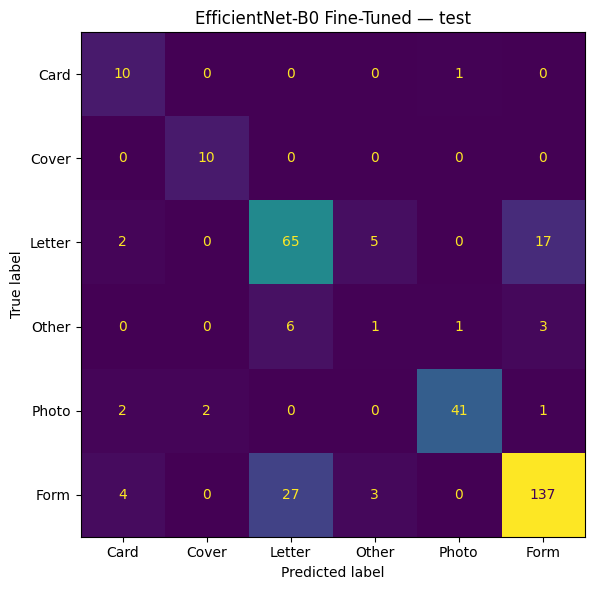

In [16]:
eff_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for p in eff_ft.features.parameters():
    p.requires_grad = False
in_features = eff_ft.classifier[1].in_features
eff_ft.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES),
)
eff_ft = eff_ft.to(DEVICE)

print('EfficientNet-B0 fine-tune …')
eff_ft = train_finetune(eff_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_eff_ft_te, probs_eff_ft = predict_image_model(eff_ft, te_img_loader)
results['EfficientNet-FT'] = evaluate('EfficientNet-B0 Fine-Tuned', y_te, pred_eff_ft_te, 'test')
results['EfficientNet-FT']['preds_te'] = pred_eff_ft_te
results['EfficientNet-FT']['probs_te'] = probs_eff_ft

### 7e. LSTM + VGG-16

Each dossier is treated as a page sequence.  
A bidirectional LSTM reads the 4096-D VGG-16 feature at each step and predicts the layout type at every position.

In [17]:
class DossierSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for _, grp in df.groupby('dossier'):
            idx   = grp.index.tolist()
            feats = X_feat[idx]
            lbls  = df.loc[idx, 'label'].values
            self.sequences.append((
                torch.tensor(feats, dtype=torch.float32),
                torch.tensor(lbls,  dtype=torch.long),
            ))

    def __len__(self): return len(self.sequences)
    def __getitem__(self, i): return self.sequences[i]


def collate_sequences(batch):
    feats, lbls = zip(*batch)
    lengths = torch.tensor([f.shape[0] for f in feats], dtype=torch.long)
    feats_pad = nn.utils.rnn.pad_sequence(feats, batch_first=True)
    lbls_pad  = nn.utils.rnn.pad_sequence(
        lbls, batch_first=True, padding_value=-1)
    return feats_pad, lbls_pad, lengths


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2,
                 dropout=0.3, n_classes=NUM_CLASSES):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        x = self.proj(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.head(out)


lstm_tr_ds = DossierSequenceDataset(df_tr, X_vgg)
lstm_va_ds = DossierSequenceDataset(df_va, X_vgg)
lstm_te_ds = DossierSequenceDataset(df_te, X_vgg)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=collate_sequences)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=collate_sequences)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=collate_sequences)

lstm_model = LSTMClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw, ignore_index=-1)
opt  = optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    lstm_model.train()
    for feats, lbls, lengths in lstm_tr_loader:
        feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
        opt.zero_grad()
        logits = lstm_model(feats, lengths)  # (B, T, C)
        loss = crit(logits.view(-1, NUM_CLASSES), lbls.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        opt.step()
    sch.step()

    lstm_model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for feats, lbls, lengths in lstm_va_loader:
            feats = feats.to(DEVICE)
            preds = lstm_model(feats, lengths).argmax(-1).cpu().numpy()
            truth = lbls.numpy()
            mask  = truth != -1
            all_true.extend(truth[mask].tolist())
            all_pred.extend(preds[mask].tolist())
    f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_state)
print(f'Best val macro-F1: {best_f1:.4f}')

  Epoch  1  val_macro_f1=0.4357
  Epoch  2  val_macro_f1=0.6314
  Epoch  3  val_macro_f1=0.7117
  Epoch  4  val_macro_f1=0.7277
  Epoch  5  val_macro_f1=0.7491
  Epoch  6  val_macro_f1=0.7990
  Epoch  7  val_macro_f1=0.7586
  Epoch  8  val_macro_f1=0.8097
  Epoch  9  val_macro_f1=0.8588
  Epoch 10  val_macro_f1=0.8196
  Epoch 11  val_macro_f1=0.7808
  Epoch 12  val_macro_f1=0.8347
  Epoch 13  val_macro_f1=0.7826
  Epoch 14  val_macro_f1=0.7816
  Epoch 15  val_macro_f1=0.7751
  Epoch 16  val_macro_f1=0.7785
  Epoch 17  val_macro_f1=0.7823
  Epoch 18  val_macro_f1=0.7844
  Epoch 19  val_macro_f1=0.7816
  Epoch 20  val_macro_f1=0.7858
Best val macro-F1: 0.8588



── LSTM + VGG-16 [test] ──
  Accuracy: 0.8077  |  Macro-F1: 0.7539
              precision    recall  f1-score   support

        Card       1.00      0.82      0.90        11
       Cover       1.00      1.00      1.00        10
      Letter       0.68      0.58      0.63        89
       Other       0.07      0.18      0.10        11
       Photo       0.96      1.00      0.98        46
        Form       0.93      0.90      0.92       171

    accuracy                           0.81       338
   macro avg       0.77      0.75      0.75       338
weighted avg       0.85      0.81      0.82       338



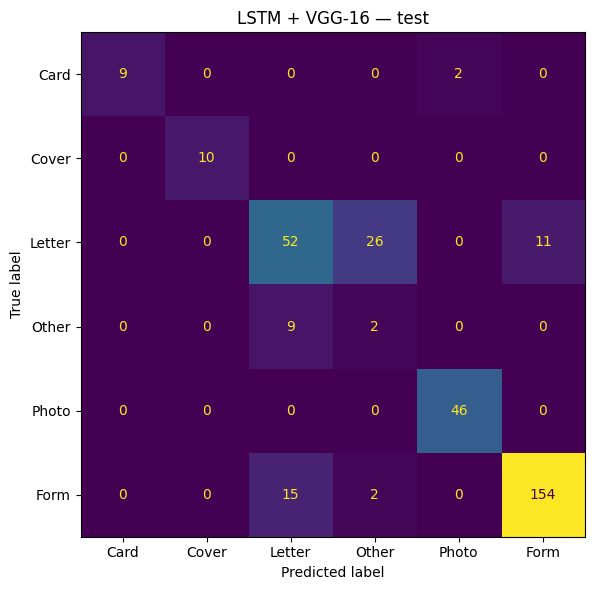

In [18]:
lstm_model.eval()
all_true_lstm, all_pred_lstm = [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        feats  = feats.to(DEVICE)
        logits = lstm_model(feats, lengths)
        preds  = logits.argmax(-1).cpu().numpy()
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds[mask].tolist())

results['LSTM-VGG16'] = evaluate(
    'LSTM + VGG-16', np.array(all_true_lstm), np.array(all_pred_lstm), 'test')
results['LSTM-VGG16']['preds_te'] = np.array(all_pred_lstm)

---
## 8. Text-Only Models

### 8a. KNN + BERT


── KNN-BERT [val] ──
  Accuracy: 0.8420  |  Macro-F1: 0.6547
              precision    recall  f1-score   support

        Card       0.58      0.65      0.61        17
       Cover       1.00      1.00      1.00        10
      Letter       0.79      0.87      0.83        91
       Other       0.00      0.00      0.00        17
       Photo       0.68      0.48      0.57        27
        Form       0.89      0.96      0.92       205

    accuracy                           0.84       367
   macro avg       0.66      0.66      0.65       367
weighted avg       0.80      0.84      0.82       367



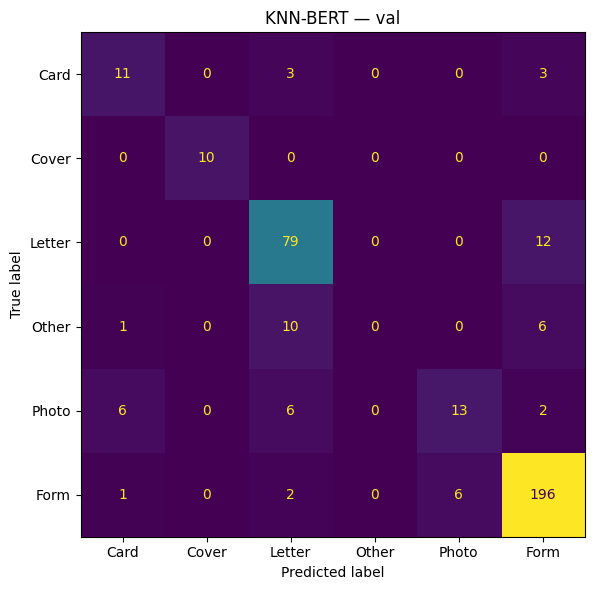


── KNN-BERT [test] ──
  Accuracy: 0.8136  |  Macro-F1: 0.6616
              precision    recall  f1-score   support

        Card       0.53      0.91      0.67        11
       Cover       1.00      1.00      1.00        10
      Letter       0.75      0.83      0.79        89
       Other       0.00      0.00      0.00        11
       Photo       0.88      0.48      0.62        46
        Form       0.86      0.93      0.90       171

    accuracy                           0.81       338
   macro avg       0.67      0.69      0.66       338
weighted avg       0.80      0.81      0.80       338



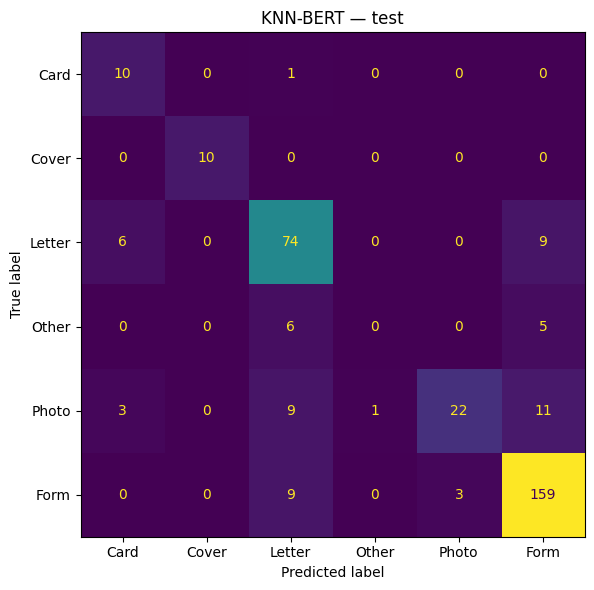

In [19]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

knn_bert = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)

pred_knn_bert_te = knn_bert.predict(X_bert_te_n)
evaluate('KNN-BERT', y_va, knn_bert.predict(X_bert_va_n), 'val')
results['KNN-BERT'] = evaluate('KNN-BERT', y_te, pred_knn_bert_te, 'test')
results['KNN-BERT']['preds_te'] = pred_knn_bert_te

### 8b. XGBoost + BERT


── XGBoost-BERT [val] ──
  Accuracy: 0.8583  |  Macro-F1: 0.6993
              precision    recall  f1-score   support

        Card       0.91      0.59      0.71        17
       Cover       1.00      1.00      1.00        10
      Letter       0.84      0.86      0.85        91
       Other       0.00      0.00      0.00        17
       Photo       0.73      0.70      0.72        27
        Form       0.87      0.97      0.92       205

    accuracy                           0.86       367
   macro avg       0.73      0.69      0.70       367
weighted avg       0.82      0.86      0.84       367



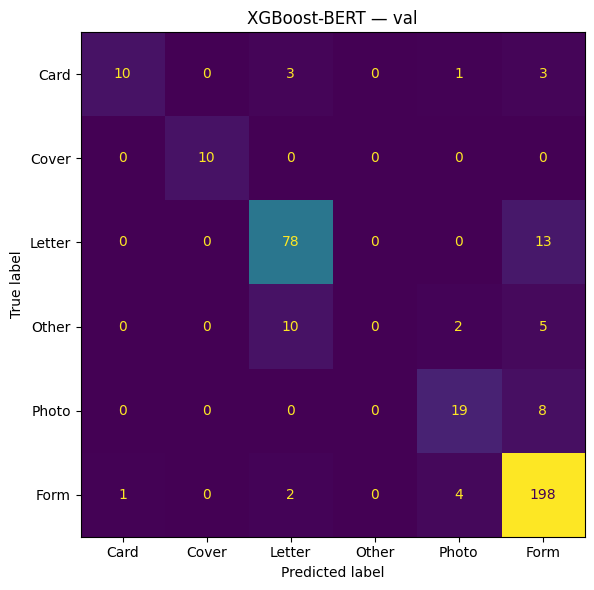


── XGBoost-BERT [test] ──
  Accuracy: 0.8580  |  Macro-F1: 0.7298
              precision    recall  f1-score   support

        Card       0.90      0.82      0.86        11
       Cover       1.00      1.00      1.00        10
      Letter       0.80      0.85      0.83        89
       Other       0.00      0.00      0.00        11
       Photo       0.87      0.72      0.79        46
        Form       0.88      0.95      0.91       171

    accuracy                           0.86       338
   macro avg       0.74      0.72      0.73       338
weighted avg       0.83      0.86      0.84       338



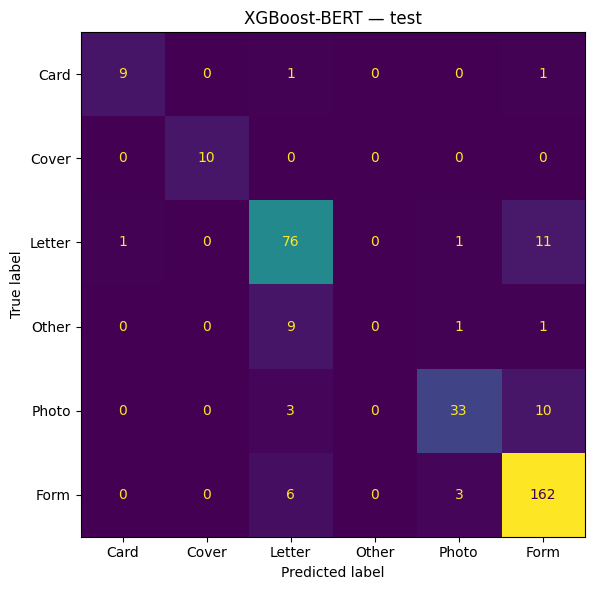

In [20]:
xgb_bert = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_bert.fit(X_bert_tr, y_tr, eval_set=[(X_bert_va, y_va)], verbose=False)
pred_xgb_bert_te = xgb_bert.predict(X_bert_te)

evaluate('XGBoost-BERT', y_va, xgb_bert.predict(X_bert_va), 'val')
results['XGBoost-BERT'] = evaluate('XGBoost-BERT', y_te, pred_xgb_bert_te, 'test')
results['XGBoost-BERT']['preds_te'] = pred_xgb_bert_te

### 8c. TEXT-CNN (frozen BERT backbone + 1D-CNN)

Frozen BERT token embeddings → multi-scale 1D convolutions → max-over-time pooling → linear classifier.

In [21]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool → MLP."""
    def __init__(self, bert_model, embed_dim=768, num_filters=128,
                 filter_sizes=(2, 3, 4), num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.bert  = bert_model
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb = out.last_hidden_state    # (B, T, E)
        x = emb.transpose(1, 2)            # (B, E, T)
        pooled = [
            F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
            for conv in self.convs
        ]
        return self.fc(self.drop(torch.cat(pooled, dim=1)))


tcnn_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_ds = TextDataset(df_tr, tcnn_tokenizer)
tcnn_va_ds = TextDataset(df_va, tcnn_tokenizer)
tcnn_te_ds = TextDataset(df_te, tcnn_tokenizer)
tcnn_tr_loader = DataLoader(tcnn_tr_ds, batch_size=16, shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(tcnn_va_ds, batch_size=16, shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(tcnn_te_ds, batch_size=16, shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)
print(f'TEXT-CNN trainable params: {sum(p.numel() for p in tcnn_model.parameters() if p.requires_grad):,}')

TEXT-CNN trainable params: 887,430


Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.7000
  Epoch  2  val_macro_f1=0.6754
  Epoch  3  val_macro_f1=0.7211
  Epoch  4  val_macro_f1=0.7644
  Epoch  5  val_macro_f1=0.7186
  Epoch  6  val_macro_f1=0.7517
  Epoch  7  val_macro_f1=0.7386
  Epoch  8  val_macro_f1=0.7457
  Epoch  9  val_macro_f1=0.7328
  Epoch 10  val_macro_f1=0.7453
  Epoch 11  val_macro_f1=0.7553
  Epoch 12  val_macro_f1=0.7500
  Epoch 13  val_macro_f1=0.7338
  Epoch 14  val_macro_f1=0.7490
  Epoch 15  val_macro_f1=0.7407

── TEXT-CNN [test] ──
  Accuracy: 0.8787  |  Macro-F1: 0.7620
              precision    recall  f1-score   support

        Card       0.85      1.00      0.92        11
       Cover       1.00      1.00      1.00        10
      Letter       0.77      0.93      0.84        89
       Other       0.00      0.00      0.00        11
       Photo       0.84      0.91      0.88        46
        Form       1.00      0.88      0.94       171

    accuracy                           0.88       338
   

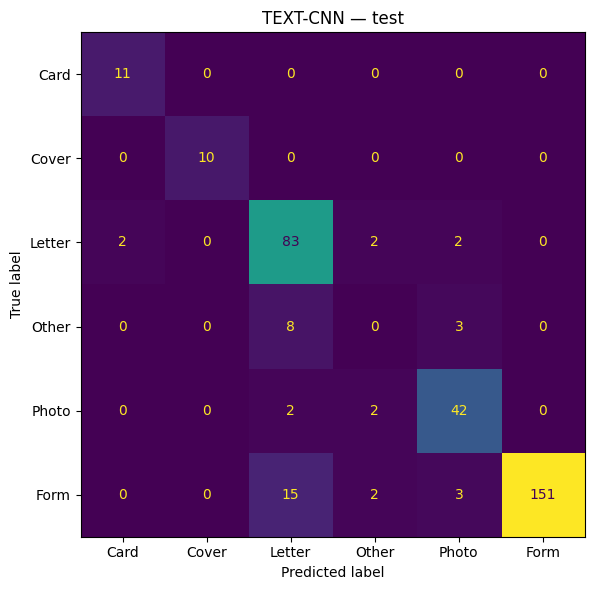

In [22]:
def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(ids, mask), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader, n_epochs=15)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)
results['TEXT-CNN'] = evaluate('TEXT-CNN', y_te, pred_tcnn_te, 'test')
results['TEXT-CNN']['preds_te'] = pred_tcnn_te
results['TEXT-CNN']['probs_te'] = probs_tcnn

### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,486,854
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.7128
  Epoch  2  val_macro_f1=0.7311
  Epoch  3  val_macro_f1=0.7395
  Epoch  4  val_macro_f1=0.7189
  Epoch  5  val_macro_f1=0.7661
  Epoch  6  val_macro_f1=0.7440
  Epoch  7  val_macro_f1=0.7575
  Epoch  8  val_macro_f1=0.7439
  Epoch  9  val_macro_f1=0.7363
  Epoch 10  val_macro_f1=0.7437

── BERT Fine-Tuned [test] ──
  Accuracy: 0.8462  |  Macro-F1: 0.7302
              precision    recall  f1-score   support

        Card       0.46      1.00      0.63        11
       Cover       1.00      1.00      1.00        10
      Letter       0.80      0.72      0.76        89
       Other       0.12      0.18      0.15        11
       Photo       0.91      0.89      0.90        46
        Form       0.97      0.92      0.95       171

    accuracy                           0.85       338
   macro avg       0.71      0.79      0.73       338
weighted avg       0.87      0.85      0.86       338


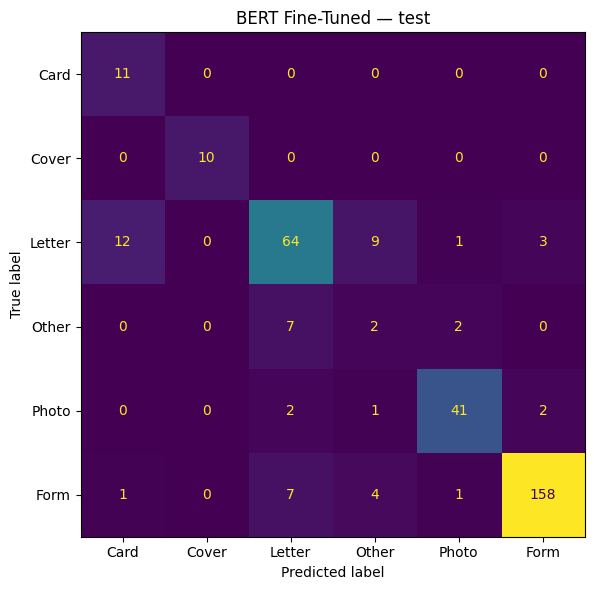

In [23]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_ds = TextDataset(df_tr, bert_ft_tokenizer)
bert_ft_va_ds = TextDataset(df_va, bert_ft_tokenizer)
bert_ft_te_ds = TextDataset(df_te, bert_ft_tokenizer)
bert_ft_tr_loader = DataLoader(bert_ft_tr_ds, batch_size=8,  shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(bert_ft_va_ds, batch_size=16, shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(bert_ft_te_ds, batch_size=16, shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)

pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
results['BERT-FT'] = evaluate('BERT Fine-Tuned', y_te, pred_bert_ft_te, 'test')
results['BERT-FT']['preds_te'] = pred_bert_ft_te
results['BERT-FT']['probs_te'] = probs_bert_ft

---
## 9. Multimodal / Fusion Models

### 9a. KNN-Ensemble (VGG-16 + BERT concatenated features)

L2-normalised VGG-16 (4096-D) and BERT (768-D) features are concatenated to form a 4864-D vector.


── KNN-Ensemble [val] ──
  Accuracy: 0.9019  |  Macro-F1: 0.7778
              precision    recall  f1-score   support

        Card       0.89      0.94      0.91        17
       Cover       1.00      1.00      1.00        10
      Letter       0.79      0.92      0.85        91
       Other       0.00      0.00      0.00        17
       Photo       0.96      0.93      0.94        27
        Form       0.97      0.96      0.96       205

    accuracy                           0.90       367
   macro avg       0.77      0.79      0.78       367
weighted avg       0.87      0.90      0.89       367



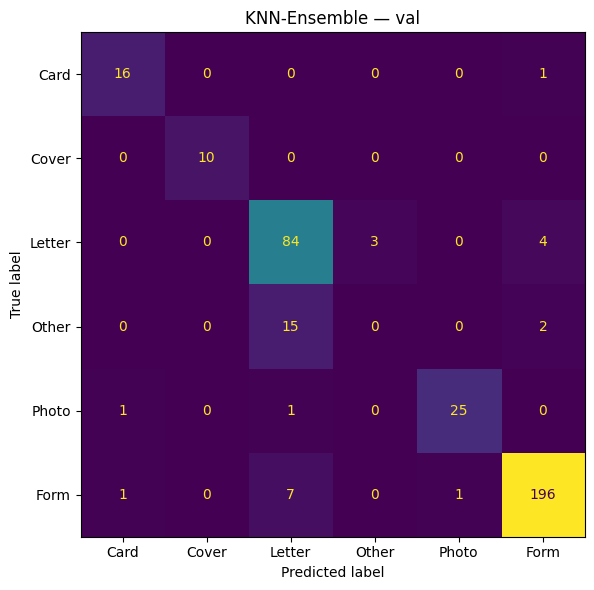


── KNN-Ensemble [test] ──
  Accuracy: 0.8905  |  Macro-F1: 0.7789
              precision    recall  f1-score   support

        Card       0.79      1.00      0.88        11
       Cover       1.00      1.00      1.00        10
      Letter       0.75      0.94      0.84        89
       Other       1.00      0.09      0.17        11
       Photo       1.00      0.72      0.84        46
        Form       0.96      0.95      0.96       171

    accuracy                           0.89       338
   macro avg       0.92      0.78      0.78       338
weighted avg       0.91      0.89      0.88       338



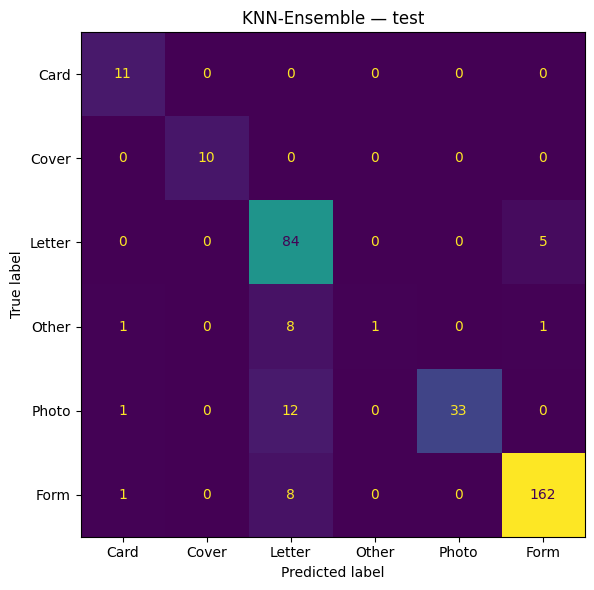

In [24]:
X_ens_tr = np.hstack([normalize(X_vgg_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_vgg_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_vgg_te), normalize(X_bert_te)])

knn_ens = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)

pred_knn_ens_te = knn_ens.predict(X_ens_te)
evaluate('KNN-Ensemble', y_va, knn_ens.predict(X_ens_va), 'val')
results['KNN-Ensemble'] = evaluate('KNN-Ensemble', y_te, pred_knn_ens_te, 'test')
results['KNN-Ensemble']['preds_te'] = pred_knn_ens_te

### 9b. XGBoost-Ensemble (VGG-16 + BERT concatenated features)


── XGBoost-Ensemble [val] ──
  Accuracy: 0.9155  |  Macro-F1: 0.7883
              precision    recall  f1-score   support

        Card       1.00      0.82      0.90        17
       Cover       1.00      1.00      1.00        10
      Letter       0.80      0.93      0.86        91
       Other       0.00      0.00      0.00        17
       Photo       1.00      1.00      1.00        27
        Form       0.95      0.98      0.96       205

    accuracy                           0.92       367
   macro avg       0.79      0.79      0.79       367
weighted avg       0.88      0.92      0.90       367



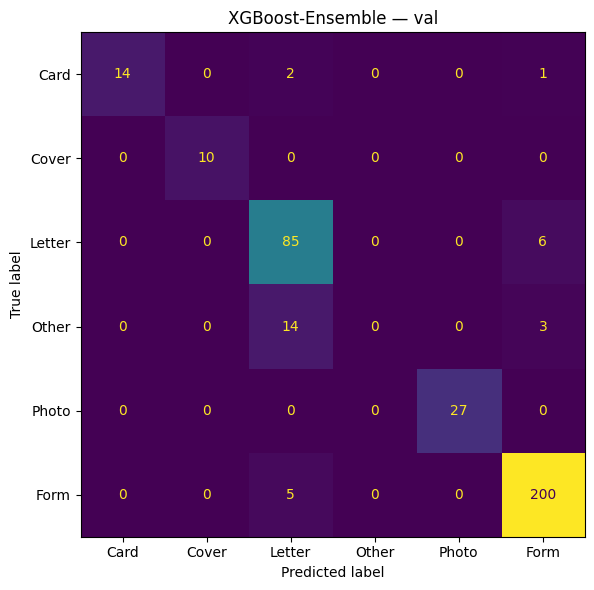


── XGBoost-Ensemble [test] ──
  Accuracy: 0.9438  |  Macro-F1: 0.8060
              precision    recall  f1-score   support

        Card       1.00      0.91      0.95        11
       Cover       1.00      1.00      1.00        10
      Letter       0.86      0.97      0.91        89
       Other       0.00      0.00      0.00        11
       Photo       1.00      1.00      1.00        46
        Form       0.97      0.98      0.97       171

    accuracy                           0.94       338
   macro avg       0.81      0.81      0.81       338
weighted avg       0.92      0.94      0.93       338



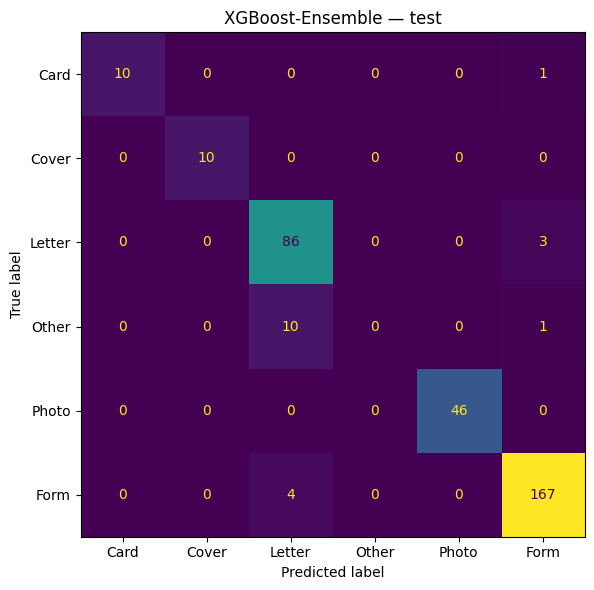

In [25]:
xgb_ens = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_ens.fit(X_ens_tr, y_tr, eval_set=[(X_ens_va, y_va)], verbose=False)
pred_xgb_ens_te = xgb_ens.predict(X_ens_te)

evaluate('XGBoost-Ensemble', y_va, xgb_ens.predict(X_ens_va), 'val')
results['XGBoost-Ensemble'] = evaluate('XGBoost-Ensemble', y_te, pred_xgb_ens_te, 'test')
results['XGBoost-Ensemble']['preds_te'] = pred_xgb_ens_te

### 9c. Early Fusion — EfficientNet-B0 + BERT → MLP

Frozen EfficientNet-B0 (1280-D) and frozen BERT [CLS] (768-D) features are **projected independently**  
then **concatenated** before a shared MLP head is trained from scratch.

  Epoch  1  val_macro_f1=0.7404
  Epoch  2  val_macro_f1=0.8171
  Epoch  3  val_macro_f1=0.8369
  Epoch  4  val_macro_f1=0.8052
  Epoch  5  val_macro_f1=0.7991
  Epoch  6  val_macro_f1=0.8083
  Epoch  7  val_macro_f1=0.8191
  Epoch  8  val_macro_f1=0.8148
  Epoch  9  val_macro_f1=0.8156
  Epoch 10  val_macro_f1=0.8590
  Epoch 11  val_macro_f1=0.8064
  Epoch 12  val_macro_f1=0.8206
  Epoch 13  val_macro_f1=0.8117
  Epoch 14  val_macro_f1=0.8164
  Epoch 15  val_macro_f1=0.8221
  Epoch 16  val_macro_f1=0.8244
  Epoch 17  val_macro_f1=0.8133
  Epoch 18  val_macro_f1=0.8178
  Epoch 19  val_macro_f1=0.8192
  Epoch 20  val_macro_f1=0.8116

── Early Fusion EfficientNet+BERT [test] ──
  Accuracy: 0.8698  |  Macro-F1: 0.7943
              precision    recall  f1-score   support

        Card       1.00      1.00      1.00        11
       Cover       1.00      1.00      1.00        10
      Letter       0.83      0.84      0.84        89
       Other       0.07      0.18      0.11        11
    

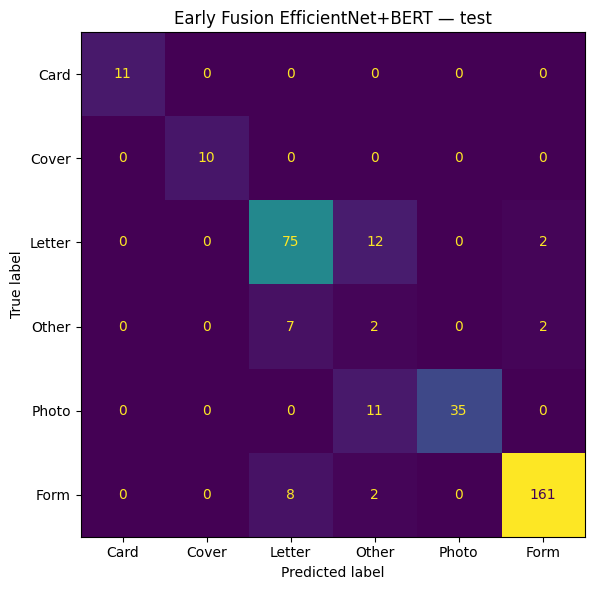

In [26]:
class EarlyFusionDataset(Dataset):
    def __init__(self, img_feats: np.ndarray, text_feats: np.ndarray, labels: np.ndarray):
        self.img    = torch.tensor(img_feats,  dtype=torch.float32)
        self.text   = torch.tensor(text_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.img[i], self.text[i], self.labels[i]


class EarlyFusionClassifier(nn.Module):
    def __init__(self, img_dim=1280, text_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim,  hidden)
        self.text_proj = nn.Linear(text_dim, hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, img_feat, text_feat):
        return self.head(torch.cat([
            self.img_proj(img_feat),
            self.text_proj(text_feat),
        ], dim=1))


ef_tr_loader = DataLoader(
    EarlyFusionDataset(X_eff_tr, X_bert_tr, y_tr), batch_size=32, shuffle=True)
ef_va_loader = DataLoader(
    EarlyFusionDataset(X_eff_va, X_bert_va, y_va), batch_size=32, shuffle=False)
ef_te_loader = DataLoader(
    EarlyFusionDataset(X_eff_te, X_bert_te, y_te), batch_size=32, shuffle=False)

ef_model = EarlyFusionClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam(ef_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    ef_model.train()
    for img_f, txt_f, yb in ef_tr_loader:
        img_f, txt_f, yb = img_f.to(DEVICE), txt_f.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(img_f, txt_f), yb).backward()
        opt.step()
    sch.step()

    ef_model.eval()
    preds = []
    with torch.no_grad():
        for img_f, txt_f, _ in ef_va_loader:
            preds.extend(ef_model(img_f.to(DEVICE), txt_f.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)
ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for img_f, txt_f, _ in ef_te_loader:
        logits = ef_model(img_f.to(DEVICE), txt_f.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())

pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)
results['EarlyFusion'] = evaluate('Early Fusion EfficientNet+BERT', y_te, pred_ef_te, 'test')
results['EarlyFusion']['preds_te'] = pred_ef_te
results['EarlyFusion']['probs_te'] = probs_ef

### 9d. Late Fusion — EfficientNet-B0 FT + BERT FT (average softmax)

The softmax probability vectors from the individually trained `EfficientNet-FT` and `BERT-FT` models  
are **averaged** to obtain the final prediction.


── Late Fusion EfficientNet+BERT [test] ──
  Accuracy: 0.8550  |  Macro-F1: 0.7371
              precision    recall  f1-score   support

        Card       0.46      1.00      0.63        11
       Cover       1.00      1.00      1.00        10
      Letter       0.81      0.73      0.77        89
       Other       0.12      0.18      0.15        11
       Photo       0.91      0.93      0.92        46
        Form       0.98      0.92      0.95       171

    accuracy                           0.86       338
   macro avg       0.72      0.80      0.74       338
weighted avg       0.88      0.86      0.86       338



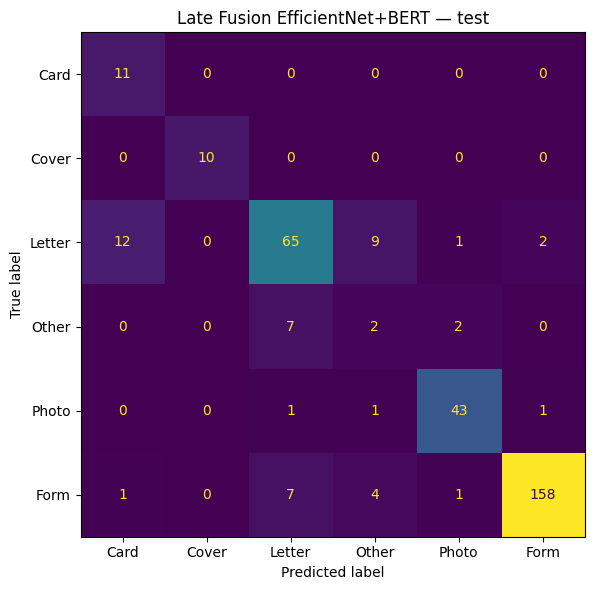

In [27]:
probs_eff_arr  = results['EfficientNet-FT']['probs_te']   # (N_te, 6)
probs_bert_arr = results['BERT-FT']['probs_te']           # (N_te, 6)

probs_late = (probs_eff_arr + probs_bert_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

results['LateFusion'] = evaluate('Late Fusion EfficientNet+BERT', y_te, pred_late, 'test')
results['LateFusion']['preds_te'] = pred_late
results['LateFusion']['probs_te'] = probs_late

## 10. Summary

In [28]:
summary_df = (
    pd.DataFrame({name: {'accuracy': v['accuracy'], 'macro_f1': v['macro_f1']}
                  for name, v in results.items()}).T
      .round(4)
)
summary_df.index.name = 'Model'
print(summary_df.to_string())
summary_df

                  accuracy  macro_f1
Model                               
KNN-VGG16           0.8846    0.7602
XGBoost-VGG16       0.9083    0.7882
VGG16-FT            0.7160    0.7187
EfficientNet-FT     0.7811    0.6914
LSTM-VGG16          0.8077    0.7539
KNN-BERT            0.8136    0.6616
XGBoost-BERT        0.8580    0.7298
TEXT-CNN            0.8787    0.7620
BERT-FT             0.8462    0.7302
KNN-Ensemble        0.8905    0.7789
XGBoost-Ensemble    0.9438    0.8060
EarlyFusion         0.8698    0.7943
LateFusion          0.8550    0.7371


,accuracy,macro_f1
Model,,
KNN-VGG16,0.8846,0.7602
XGBoost-VGG16,0.9083,0.7882
VGG16-FT,0.7160,0.7187
EfficientNet-FT,0.7811,0.6914
LSTM-VGG16,0.8077,0.7539
KNN-BERT,0.8136,0.6616
XGBoost-BERT,0.8580,0.7298
TEXT-CNN,0.8787,0.7620
BERT-FT,0.8462,0.7302


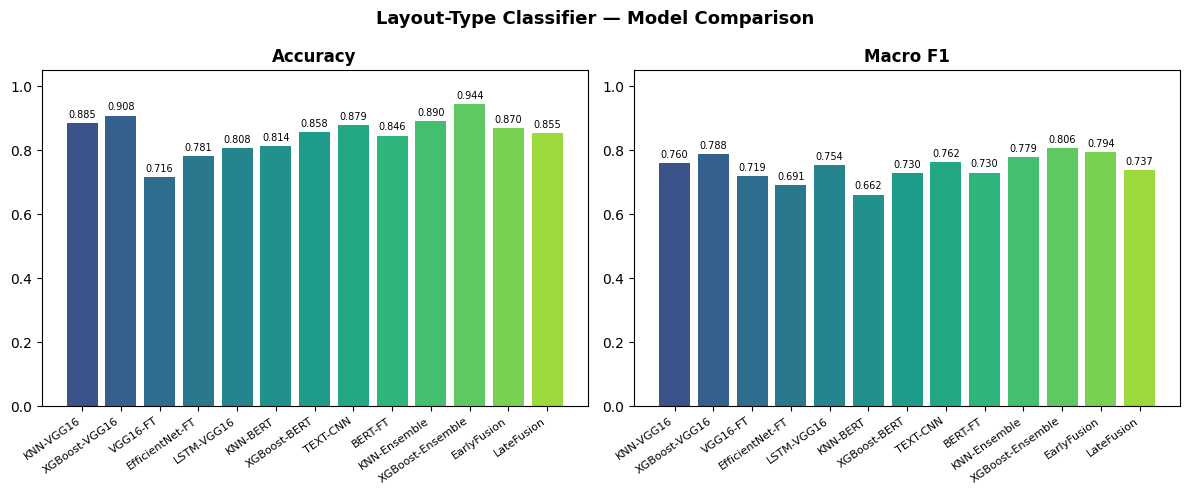

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['accuracy', 'macro_f1']):
    vals   = summary_df[metric].astype(float)
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(vals)))
    bars   = ax.bar(vals.index, vals.values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Layout-Type Classifier — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()